# Optimization Is a Deterministic Recursion (and Sometimes Chaos)

Gradient descent looks like an algorithm, but it is a **dynamical system**: a deterministic recursion

$$x_{n+1} = g(x_n),\qquad g(x) = x - \eta\,f'(x).$$

The minimum is a **fixed point**, convergence is **contraction** ($|g'(x^*)|<1$), and when the step
$\eta$ grows too bold the very same recursion **period-doubles into chaos**. This notebook tells that
story symbolically (SymPy solves the recurrence in closed form) and visually (cobwebs, a bifurcation
diagram), then connects it to the repo's Gerchberg-Saxton loop — itself an optimization recursion.
Engine: `opt_recursion.py`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math

import opt_recursion as opt

sp.init_printing(use_latex="mathjax")
x, a, eta, x0 = sp.symbols("x a eta x_0", positive=True)
print("opt_recursion loaded")

opt_recursion loaded


## §1 Optimization *creates* a symbolic recursion

For the simplest objective $f=\tfrac{a}{2}x^2$, gradient descent is the *linear* recurrence
$x_{n+1}=(1-\eta a)\,x_n$. SymPy's `rsolve` returns its closed form, and the contraction factor
$1-\eta a$ tells you everything: converge for $0<\eta<2/a$, oscillate as it nears $2/a$, diverge
beyond.

In [2]:
xn, factor = opt.gd_closed_form(a, x0, eta)
display(Math(r"x_{n+1} = (1-\eta a)\,x_n \;\Rightarrow\; x_n = " + sp.latex(xn)))
display(Math(r"\text{contraction factor } = " + sp.latex(factor)
             + r",\quad \text{converges} \iff |1-\eta a|<1 \iff 0<\eta<\tfrac{2}{a}"))

# fixed-point stability of GD on the same f
for xs, mult, cond in opt.fixed_point_stability(a/2 * x**2, x, eta):
    display(Math(r"x^*=" + sp.latex(xs) + r",\quad g'(x^*)=" + sp.latex(mult)
                 + r",\quad \text{stable when } " + sp.latex(cond)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## §2 Watch the recursion unroll: three regimes

Same objective ($a=1$), three step sizes. The closed-form $(1-\eta)^n x_0$ (dashed) lies exactly on
the iterates (dots): **monotone** decay ($\eta=0.5$), **oscillatory** decay ($\eta=1.5$, factor
$-0.5$), and **divergence** ($\eta=2.1$, factor $-1.1$).

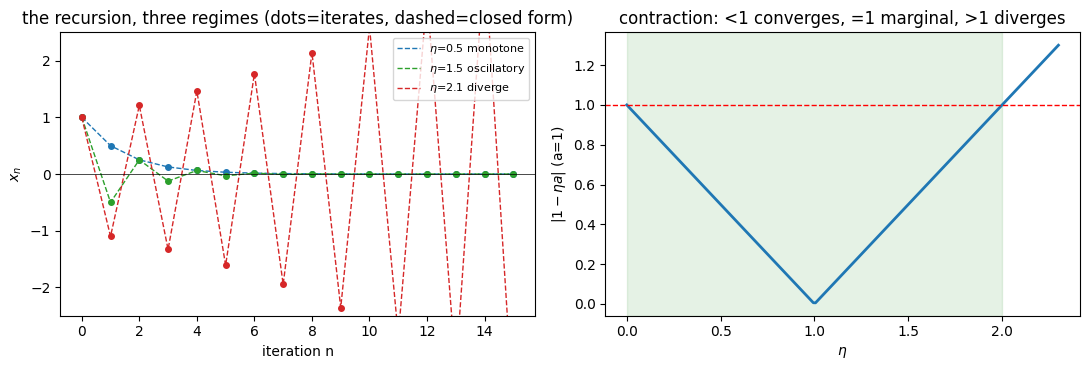

In [3]:
ns = np.arange(0, 16)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for e, lab, col in [(0.5, "$\\eta$=0.5 monotone", "C0"),
                    (1.5, "$\\eta$=1.5 oscillatory", "C2"),
                    (2.1, "$\\eta$=2.1 diverge", "C3")]:
    g = opt.gd_step(lambda v: v, e)
    traj = opt.iterate_map(g, 1.0, 15)
    ax[0].plot(ns, traj, "o", color=col, ms=4)
    ax[0].plot(ns, (1 - e)**ns * 1.0, "--", color=col, lw=1, label=lab)
ax[0].axhline(0, color="k", lw=0.5); ax[0].set_ylim(-2.5, 2.5)
ax[0].set_xlabel("iteration n"); ax[0].set_ylabel("$x_n$"); ax[0].legend(fontsize=8)
ax[0].set_title("the recursion, three regimes (dots=iterates, dashed=closed form)")

# convergence-factor curve
es = np.linspace(0, 2.3, 200)
ax[1].plot(es, np.abs(1 - es), lw=2)
ax[1].axhline(1, color="r", ls="--", lw=1); ax[1].axvspan(0, 2, alpha=0.1, color="green")
ax[1].set_xlabel("$\\eta$"); ax[1].set_ylabel("$|1-\\eta a|$ (a=1)")
ax[1].set_title("contraction: <1 converges, =1 marginal, >1 diverges")
plt.tight_layout(); plt.show()

## §3 The cobweb: the geometry of iteration

Plot $y=g(x)$ against the diagonal $y=x$ and bounce between them — the staircase *is* the optimizer
descending. Where $g$ crosses the diagonal is the fixed point; the slope there ($g'(x^*)$) is the
convergence rate.

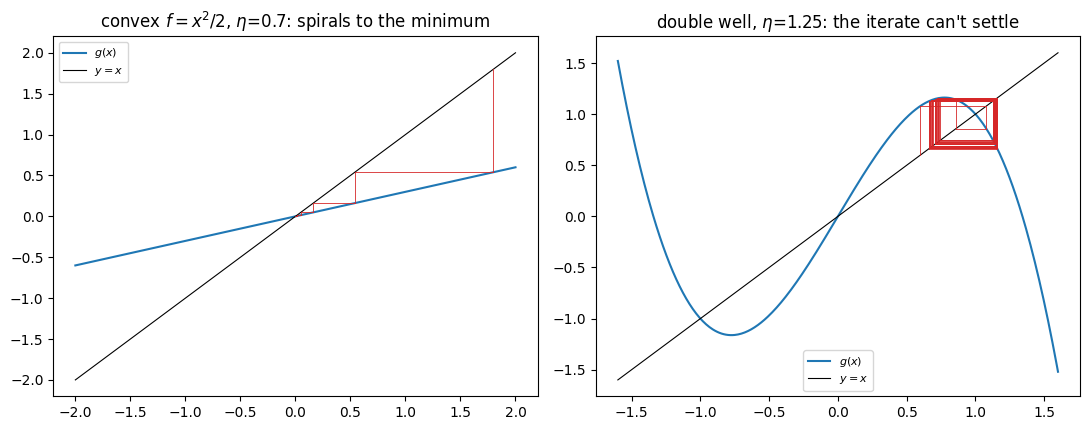

In [4]:
def cobweb(ax, g, x0v, n, xr, title):
    xs = np.linspace(*xr, 400)
    ax.plot(xs, g(xs), "C0", lw=1.5, label="$g(x)$")
    ax.plot(xs, xs, "k", lw=0.8, label="$y=x$")
    v = x0v
    for _ in range(n):
        gv = g(v)
        ax.plot([v, v], [v, gv], "C3", lw=0.6)
        ax.plot([v, gv], [gv, gv], "C3", lw=0.6)
        v = gv
        if not np.isfinite(v) or abs(v) > xr[1]*2:
            break
    ax.set_title(title); ax.legend(fontsize=8)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
cobweb(ax[0], opt.gd_step(lambda v: v, 0.7), 1.8, 20, (-2, 2),
       "convex $f=x^2/2$, $\\eta$=0.7: spirals to the minimum")
# double-well f=x^4/4 - x^2/2, f'=x^3-x, eta=1.25 -> oscillatory/chaotic
cobweb(ax[1], opt.gd_step(lambda v: v**3 - v, 1.25), 0.6, 40, (-1.6, 1.6),
       "double well, $\\eta$=1.25: the iterate can't settle")
plt.tight_layout(); plt.show()

## §4 The headline: optimization that boils over into chaos

On the **double well** $f=\tfrac14x^4-\tfrac12x^2$ (minima at $\pm1$), the GD map at a minimum has
multiplier $1-2\eta$. It crosses $-1$ at $\eta=1$ — a **period-doubling bifurcation** — and as $\eta$
grows further the optimizer cascades 1 $\to$ 2 $\to$ 4 $\to \dots \to$ **chaos**, never converging.
Too large a learning rate doesn't just fail; it makes the dynamics strange.

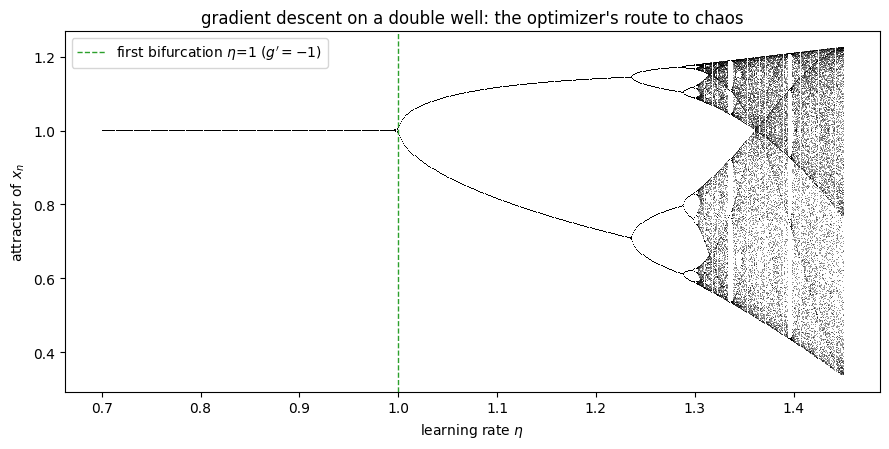

below eta=1: converges to a minimum. above: period-2, period-4, ..., chaos.


In [5]:
etas = np.linspace(0.7, 1.45, 700)
E, X = opt.bifurcation(lambda v: v**3 - v, etas, x0=0.95)
plt.figure(figsize=(9, 4.6))
plt.plot(E, X, ",", color="k", alpha=0.4)
plt.axvline(1.0, color="C2", ls="--", lw=1, label="first bifurcation $\\eta$=1 ($g'=-1$)")
plt.xlabel("learning rate $\\eta$"); plt.ylabel("attractor of $x_n$")
plt.title("gradient descent on a double well: the optimizer's route to chaos")
plt.legend(); plt.tight_layout(); plt.show()
print("below eta=1: converges to a minimum. above: period-2, period-4, ..., chaos.")

## §5 In higher dimensions: the condition number sets the pace

For $f=\tfrac12(x^2+\kappa y^2)$ the two axes contract at different rates; the slowest sets
convergence. With optimal $\eta$ the rate is $\frac{\kappa-1}{\kappa+1}$ — ill-conditioned problems
($\kappa\gg1$) zig-zag down a narrow valley. This is *the* reason preconditioning and momentum exist.

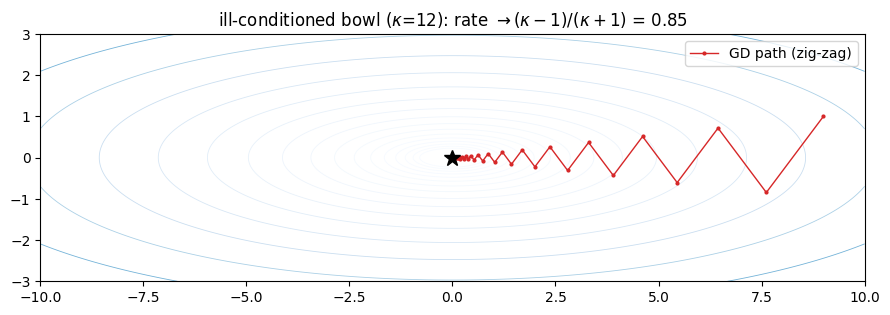

In [6]:
kappa = 12.0
fp = lambda p: np.array([p[0], kappa*p[1]])     # grad of (x^2 + kappa y^2)/2
eta = 2.0/(1+kappa)                             # optimal step
p = np.array([9.0, 1.0]); path = [p.copy()]
for _ in range(40):
    p = p - eta*fp(p); path.append(p.copy())
path = np.array(path)

gx, gy = np.meshgrid(np.linspace(-10, 10, 200), np.linspace(-3, 3, 200))
Z = 0.5*(gx**2 + kappa*gy**2)
plt.figure(figsize=(9, 3.2))
plt.contour(gx, gy, Z, levels=np.logspace(-0.5, 2.2, 18), cmap="Blues", linewidths=0.6)
plt.plot(path[:,0], path[:,1], "C3.-", ms=4, lw=1, label="GD path (zig-zag)")
plt.plot(0, 0, "k*", ms=12); plt.gca().set_aspect("equal")
plt.title(f"ill-conditioned bowl ($\\kappa$={kappa:.0f}): rate $\\to (\\kappa-1)/(\\kappa+1)$ = {(kappa-1)/(kappa+1):.2f}")
plt.legend(); plt.tight_layout(); plt.show()

## §6 The repo: Gerchberg-Saxton is an optimization recursion

The TD-GS phase-retrieval loop is exactly this story. Each iteration
$E_{n+1}=\mathcal P_2\,\mathcal P_1\,E_n$ is a deterministic recursion — alternating projections
onto the two intensity-constraint sets — and it *is* an optimizer, minimizing constraint violation.

- **Convergence = contraction**, governed by the spectrum of the composed projection operator, just
  like $|1-\eta a|$ here.
- **The $|D|\approx5000$ diversity window** is the regime where the two constraint sets are
  transverse enough that the composition contracts; too little dispersion and the operator's leading
  multiplier sits near $1$ — the recursion stalls, exactly the $\eta\to0$ / marginal-stability edge.
- **Step too bold $\to$ chaos** is the cautionary mirror: more iterations or a more aggressive update
  is not always better; a recursion has a stable operating window, and engineering is finding it.

*One idea, three faces:* a recurrence you can solve symbolically (SymPy `rsolve`), a dynamical system
you can watch evolve and bifurcate, and the convergence theory behind every optimizer in the repo —
from GS to the FNO's training loop.

Module added: `opt_recursion.py` (`gd_closed_form`, `fixed_point_stability`, `iterate_map`,
`bifurcation`), benchmarked in `scripts/smoke_opt_recursion.py`.